In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "whitegrid")
warnings.filterwarnings("ignore")

In [3]:
# reading the data
df = pd.read_csv("../data/data_cleaned.csv")
df.drop(columns = ["Unnamed: 0"], inplace = True)
df.head()

,gre_score,toefl_score,university_rating,sop,lor,cgpa,research,chance_of_admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
# separating features and labels
x = df.drop(columns = "chance_of_admit")
y = df["chance_of_admit"]
x.shape, y.shape

((497, 7), (497,))

In [5]:
# train-test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((397, 7), (100, 7), (397,), (100,))

In [6]:
# feature scaling and transformation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [7]:
# model building

In [8]:
# linear regression
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

# training the linear regression model
lr_model.fit(x_train, y_train)

LinearRegression()

In [9]:
# saving the model into a .pkl file
import pickle

with open("../artifacts/lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

In [10]:
# predictions
y_predicted = lr_model.predict(x_test)

In [11]:
# comments on model statistics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
print("----- Model Statistics: Linear Regression -----")
train_performance = lr_model.score(x_train, y_train)
print(f"Training performance = {train_performance}")
test_performance = lr_model.score(x_test, y_test)
print(f"Test performance = {test_performance}")
mse = mean_squared_error(y_test, y_predicted)
print(f"MSE = {mse}")
r2 = r2_score(y_test, y_predicted)
print(f"R2 Score = {r2}")
mae = mean_absolute_error(y_test, y_predicted)
print(f"MAE = {mae}")
rmse = np.sqrt(mse)
print(f"RMSE = {rmse}")
adjr2 = 1 - ((1 - r2) * (len(y) - 1)/ ((len(y) - x.shape[1] - 1)))
print(f"Adjusted R2 Score = {adjr2}")

----- Model Statistics: Linear Regression -----
Training performance = 0.8261392753723373
Test performance = 0.7958581715074224
MSE = 0.003673319896222301
R2 Score = 0.7958581715074224
MAE = 0.043640469350628194
RMSE = 0.060607919418359024
Adjusted R2 Score = 0.7929358958439295


In [12]:
# model coefficients
print("-"*50)
print("Model Coefficients: Linear Regression")
print("-"*50)
column_names = list(df.columns)
print(column_names)

for i in range(len(column_names) - 1):
    print(f"{column_names[i]} = {lr_model.coef_[i]}")

--------------------------------------------------
Model Coefficients: Linear Regression
--------------------------------------------------
['gre_score', 'toefl_score', 'university_rating', 'sop', 'lor', 'cgpa', 'research', 'chance_of_admit']
gre_score = 0.022374345462375805
toefl_score = 0.018305137095739207
university_rating = 0.002382711489305126
sop = 0.005019114772415293
lor = 0.016540565183535885
cgpa = 0.06817486216837958
research = 0.011177608337611536


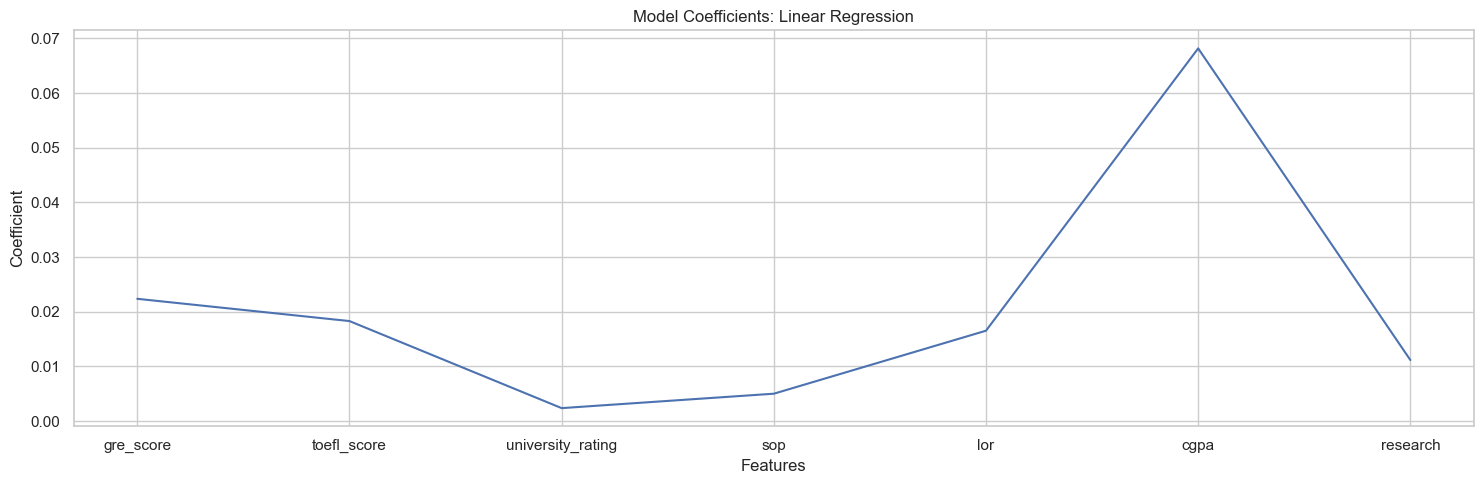

In [13]:
# visualization of model coefficients
plt.figure(figsize = (15, 5))
plt.plot(column_names[0: -1], lr_model.coef_)
plt.title("Model Coefficients: Linear Regression")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.savefig("../artifacts/linear_regression_model_coefficients.png")
plt.show()

In [14]:
# ridge regression
from sklearn.linear_model import Ridge

# building the ridge regression model using train set
ridge_model = Ridge()
ridge_model.fit(x_train, y_train)

Ridge()

In [15]:
# predictions
y_ridge_predicted = ridge_model.predict(x_test)

In [16]:
# model statistics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
print("----- Model Statistics: Ridge Regression -----")
train_performance = ridge_model.score(x_train, y_train)
print(f"Training performance = {train_performance}")
test_performance = ridge_model.score(x_test, y_test)
print(f"Test performance = {test_performance}")
mse = mean_squared_error(y_test, y_ridge_predicted)
print(f"MSE = {mse}")
r2 = r2_score(y_test, y_ridge_predicted)
print(f"R2 Score = {r2}")
mae = mean_absolute_error(y_test, y_ridge_predicted)
print(f"MAE = {mae}")
rmse = np.sqrt(mse)
print(f"RMSE = {rmse}")
adjr2 = 1 - ((1 - r2) * (len(y) - 1)/ ((len(y) - x.shape[1] - 1)))
print(f"Adjusted R2 Score = {adjr2}")

----- Model Statistics: Ridge Regression -----
Training performance = 0.8261347965926602
Test performance = 0.7956587073942554
MSE = 0.003676909045496064
R2 Score = 0.7956587073942554
MAE = 0.04367711686561249
RMSE = 0.06063752176248683
Adjusted R2 Score = 0.7927335764162591


In [17]:
# model coefficients
print("-"*50)
print("Model Coefficients: Ridge Regression")
print("-"*50)
column_names = list(df.columns)
column_names

for i in range(len(column_names) - 1):
    print(f"{column_names[i]} = {ridge_model.coef_[i]}")

--------------------------------------------------
Model Coefficients: Ridge Regression
--------------------------------------------------
gre_score = 0.022556762336687495
toefl_score = 0.018435400674081483
university_rating = 0.002499735978133235
sop = 0.005147469227411206
lor = 0.016592364653661266
cgpa = 0.06754331166590241
research = 0.011169035571279802


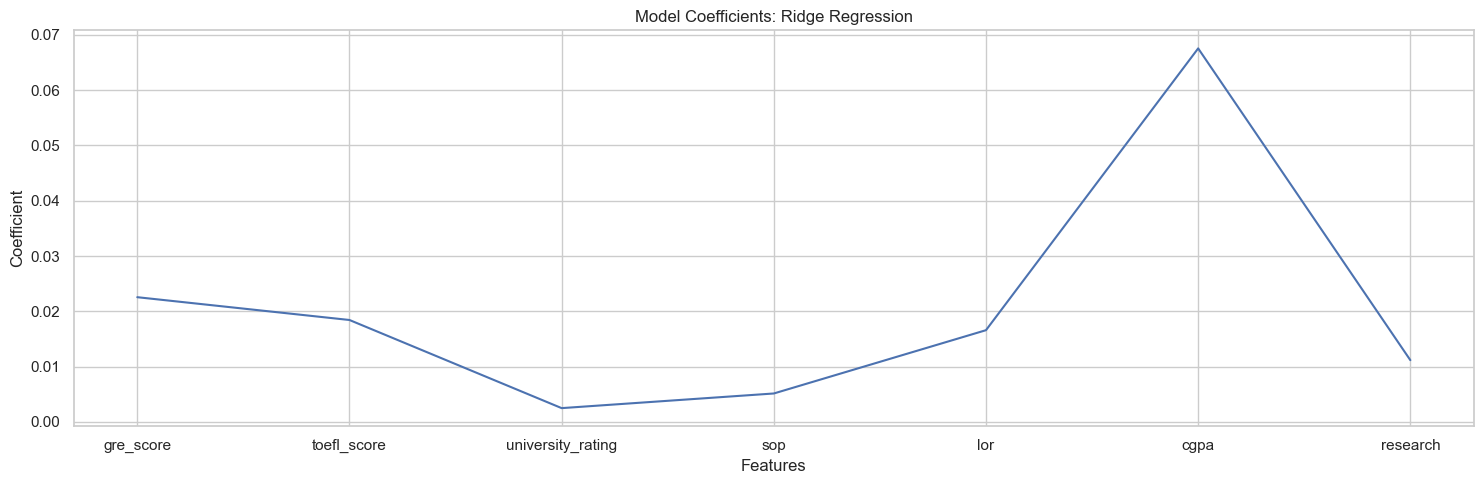

In [18]:
# visualizing model coefficients
plt.figure(figsize = (15, 5))
plt.plot(column_names[0: -1], ridge_model.coef_)
plt.title("Model Coefficients: Ridge Regression")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.savefig("../artifacts/ridge_regression_model_coefficients.png")
plt.show()

In [19]:
# lasso regression
from sklearn.linear_model import Lasso

# training
lasso_model = Lasso()
lasso_model.fit(x_train, y_train)

Lasso()

In [20]:
# predictions
y_lasso_predicted = lasso_model.predict(x_test)

In [21]:
# model statistics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
print("----- Model Statistics: Lasso Regression -----")
train_performance = lasso_model.score(x_train, y_train)
print(f"Training performance = {train_performance}")
test_performance = lasso_model.score(x_test, y_test)
print(f"Test performance = {test_performance}")
mse = mean_squared_error(y_test, y_lasso_predicted)
print(f"MSE = {mse}")
r2 = r2_score(y_test, y_lasso_predicted)
print(f"R2 Score = {r2}")
mae = mean_absolute_error(y_test, y_lasso_predicted)
print(f"MAE = {mae}")
rmse = np.sqrt(mse)
print(f"RMSE = {rmse}")
adjr2 = 1 - ((1 - r2) * (len(y) - 1)/ ((len(y) - x.shape[1] - 1)))
print(f"Adjusted R2 Score = {adjr2}")

----- Model Statistics: Lasso Regression -----
Training performance = 0.0
Test performance = -0.04885279753095717
MSE = 0.018873015284660143
R2 Score = -0.04885279753095717
MAE = 0.10657581863979854
RMSE = 0.13737909333177353
Adjusted R2 Score = -0.0638670502563492


In [22]:
# model coefficients
print("-"*50)
print("Model Coefficients: Lasso Regression")
print("-"*50)
column_names = list(df.columns)
column_names

for i in range(len(column_names) - 1):
    print(f"{column_names[i]} = {lasso_model.coef_[i]}")

--------------------------------------------------
Model Coefficients: Lasso Regression
--------------------------------------------------
gre_score = 0.0
toefl_score = 0.0
university_rating = 0.0
sop = 0.0
lor = 0.0
cgpa = 0.0
research = 0.0


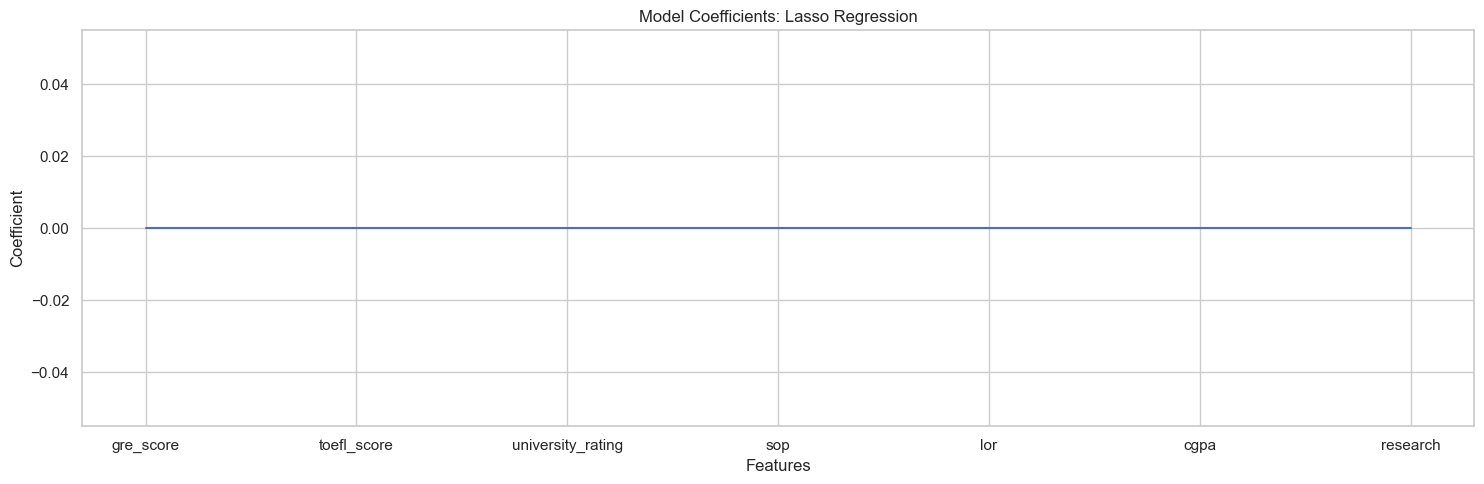

In [23]:
# visualizing model coefficients
plt.figure(figsize = (15, 5))
plt.plot(column_names[0:-1], lasso_model.coef_)
plt.title("Model Coefficients: Lasso Regression")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.savefig("../artifacts/lasso_regression_model_coefficients.png")
plt.show()

In [24]:
# testing the assumptions of linear regression model

In [25]:
# model building
lr_model = LinearRegression()
# training
lr_model.fit(x_train, y_train)
# predictions
y_predicted = lr_model.predict(x_test)

In [26]:
# multi-collinearity check by VIF score (VIF scores should be below 5, which is the defined limit)
from statsmodels.stats.outliers_influence import variance_inflation_factor

col = df[["gre_score", "toefl_score", "university_rating", "sop", "lor", "cgpa",
       "research", "chance_of_admit"]]
x1 = np.array(x_train)
vif = []
for i in range(x1.shape[1]):
    vif.append(round(variance_inflation_factor(x1, i),2))

vif_score= pd.DataFrame({
    'Columns':["gre_score", "toefl_score", "university_rating", "sop", "lor", "cgpa", "research"],
    'VIF score': vif
})
vif_score

,Columns,VIF score
0,gre_score,4.34
1,toefl_score,3.65
2,university_rating,2.70
3,sop,2.93
4,lor,2.11
5,cgpa,4.98
6,research,1.51


In [27]:
# mean value of residuals should be nearly zero
residuals = y_train - lr_model.predict(x_train)
mean_residuals = np.mean(residuals)
print(f"Mean of Residuals = {mean_residuals}")

Mean of Residuals = 5.033756786713556e-18


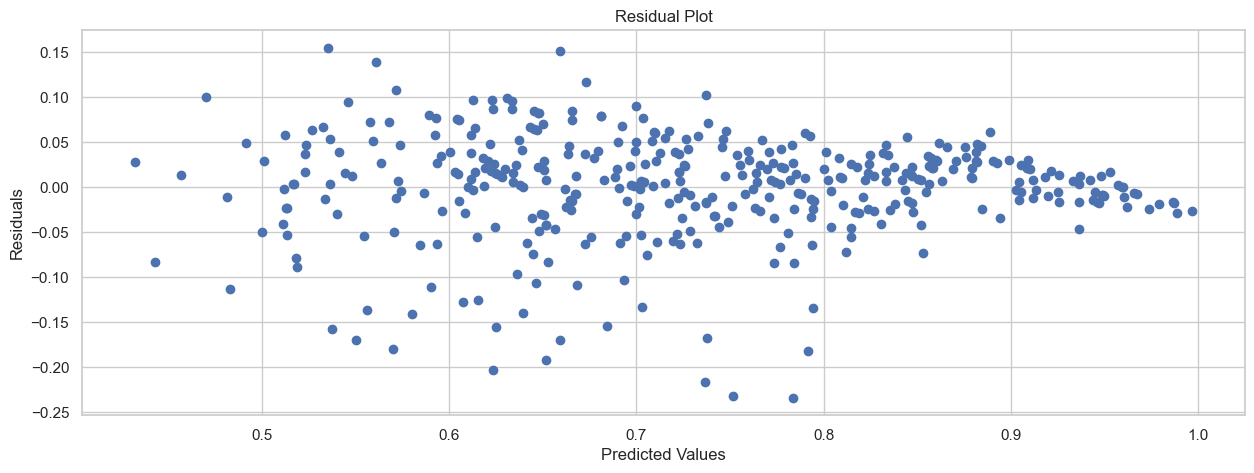

In [28]:
# linearity of variables
plt.figure(figsize = (15, 5))
plt.scatter(lr_model.predict(x_train), residuals)
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.savefig("../artifacts/linearity_of_variables.png")
plt.show()

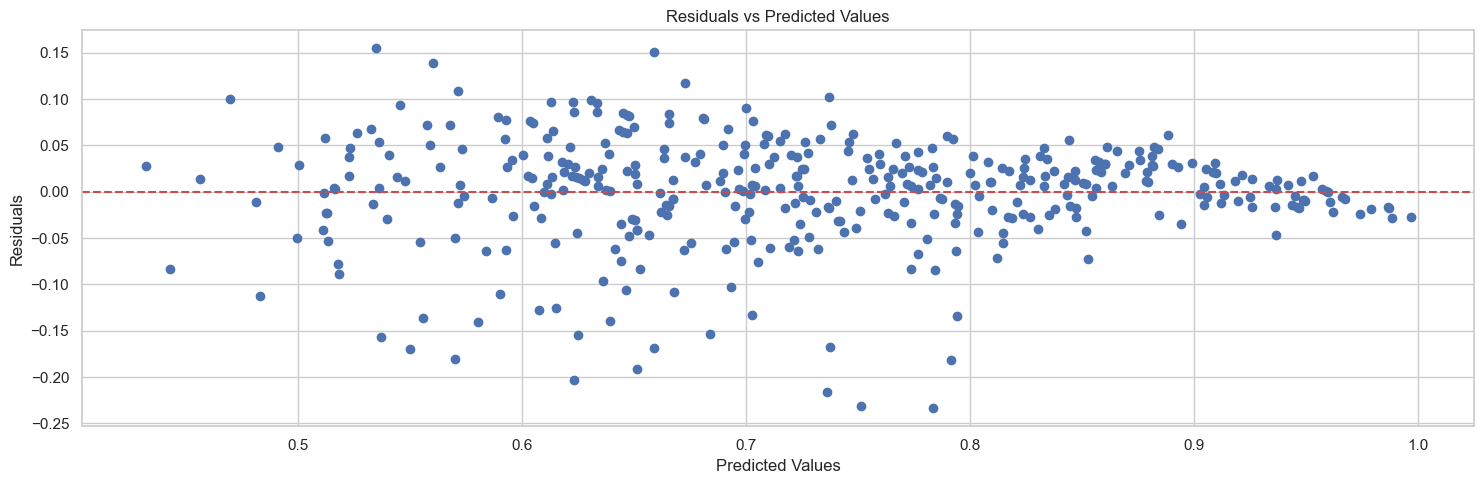

In [29]:
# test for homoskedasticity
plt.figure(figsize = (15, 5))
plt.scatter(lr_model.predict(x_train), residuals)
plt.axhline(y = 0, color = "r", linestyle = "--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("../artifacts/homoskedasticity.png")
plt.show()

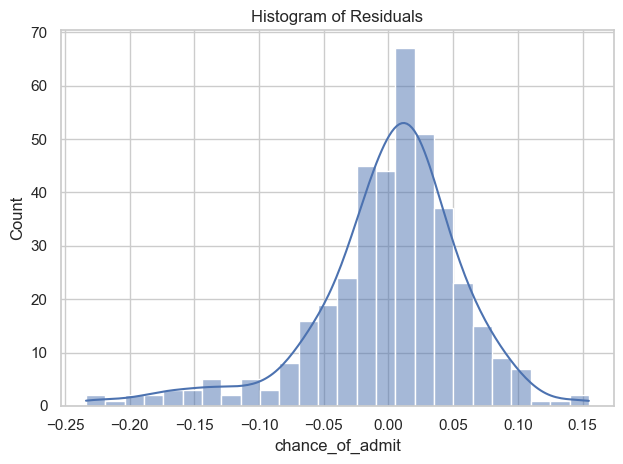

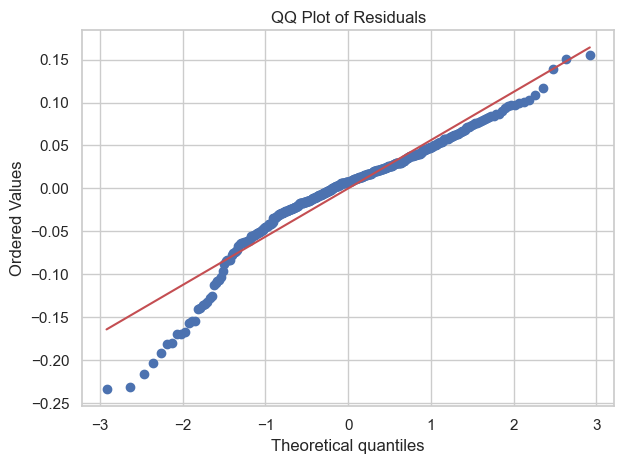

In [30]:
# normality of residuals
from scipy.stats import probplot

# histogram
sns.histplot(residuals, kde = True)
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.savefig("../artifacts/normality_of_residuals_histogram_of_residuals.png")
plt.show()

# qq-plot
probplot(residuals, plot = plt)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.savefig("../artifacts/normality_of_residuals_qq_plot_of_residuals.png")
plt.show()

In [31]:
# performance evaluation

In [32]:
# mae, rmse, r2, adj-r2
mse = mean_squared_error(y_test, y_predicted)
print(f"MSE = {mse}")
r2 = r2_score(y_test, y_predicted)
print(f"R2 Score = {r2}")
mae = mean_absolute_error(y_test, y_predicted)
print(f"MAE = {mae}")
rmse = np.sqrt(mse)
print(f"RMSE = {rmse}")
adjr2 = 1 - ((1 - r2) * (len(y) - 1)/ ((len(y) - x.shape[1] - 1)))
print(f"Adjusted R2 Score = {adjr2}")

MSE = 0.003673319896222301
R2 Score = 0.7958581715074224
MAE = 0.043640469350628194
RMSE = 0.060607919418359024
Adjusted R2 Score = 0.7929358958439295


In [33]:
# train and test performance check
train_performance = lr_model.score(x_train, y_train)
print(f"Training performance = {train_performance}")
test_performance = lr_model.score(x_test, y_test)
print(f"Test performance = {test_performance}")

Training performance = 0.8261392753723373
Test performance = 0.7958581715074224


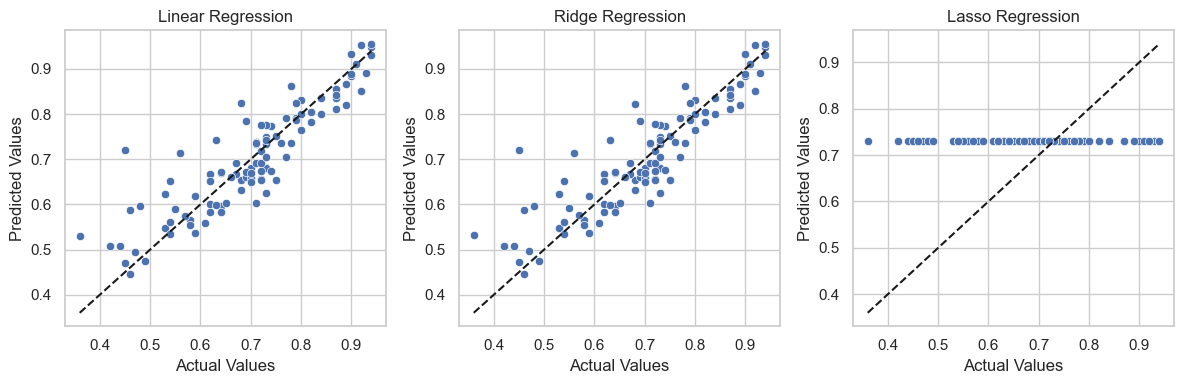

In [34]:
# comments on the performance measures and if there is any need to improve the model or not

# best model
actual_values = y_test.values.reshape((-1))
predicted_values = [y_predicted.reshape((-1)), y_ridge_predicted.reshape((-1)), y_lasso_predicted.reshape((-1))]
model = ["Linear Regression", "Ridge Regression", "Lasso Regression"]

plt.figure(figsize=(12, 4))
i = 1
for preds in predicted_values:
    ax = plt.subplot(1, 3, i)
    sns.scatterplot(x=actual_values, y=preds)
    plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], 'k--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(model[i-1])
    i += 1

plt.tight_layout()
plt.savefig("../artifacts/best_model.png")
plt.show()